In [3]:
# =========================================================
# 🧙‍♂️ Télécharger le dataset Kaggle "Harry Potter Cast Face Recognition"
# =========================================================

# 1️⃣ Installer l'outil Kaggle
!pip install -q kaggle

# 2️⃣ Importer le module pour uploader ta clé kaggle.json
from google.colab import files
import os, zipfile

# print("➡️  Upload ton fichier kaggle.json (téléchargé depuis ton profil Kaggle)")
# uploaded = files.upload()

# # 3️⃣ Sauvegarder la clé au bon endroit
# os.makedirs("/root/.kaggle", exist_ok=True)
# with open("/root/.kaggle/kaggle.json", "wb") as f:
#     f.write(uploaded["kaggle.json"])
# os.chmod("/root/.kaggle/kaggle.json", 0o600)

# # 4️⃣ Télécharger le dataset Harry Potter depuis Kaggle
# !kaggle datasets download -d alexday11/harry-potter-cast-face-recognition -p /content

# 5️⃣ Décompresser le dataset
zip_path = "/content/harry-potter-cast-face-recognition.zip"
extract_dir = "/content/harry_potter_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ Dataset téléchargé et extrait ici :", extract_dir)

# 6️⃣ Afficher le contenu du dossier
!ls -l /content/harry_potter_dataset


✅ Dataset téléchargé et extrait ici : /content/harry_potter_dataset
total 224
-rw-r--r--  1 root root 222110 May 13 09:57 emma.jpg
drwxr-xr-x 18 root root   4096 May 13 09:56 Images


Installation & imports

In [4]:
# =========================================================
# 📦 Install & Imports
# =========================================================
!pip -q install facenet-pytorch==2.5.3 timm==1.0.9 torchmetrics==1.4.0

import os, shutil, random, glob, json, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from facenet_pytorch import MTCNN, InceptionResnetV1

from facenet_pytorch import InceptionResnetV1

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import itertools

from torch.utils.data import WeightedRandomSampler
from collections import Counter

from google.colab import files
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 22.9 MB/s eta 0:00:00


device(type='cuda')

Localiser les images & préparer les dossiers

In [5]:
# =========================================================
# 📁 Paths & dataset check
# =========================================================
ROOT = Path("/content/harry_potter_dataset")
images_dir = (ROOT / "Images")
if not images_dir.exists():
    images_dir = (ROOT / "Immages")  # certains zips ont cette orthographe

assert images_dir.exists(), f"Impossible de trouver {images_dir}"

cropped_root = Path("/content/hp_faces_cropped")
for p in [cropped_root]:
    p.mkdir(parents=True, exist_ok=True)

print("Images source  :", images_dir)
print("Cropped output :", cropped_root)

# mapping acteurs -> personnages
actor_to_character = {
    "Alan Rickman": "Severus Snape",
    "Alfred Enoch": "Dean Thomas",
    "Bonnie Wright": "Ginny Weasley",
    "Daniel Radcliffe": "Harry Potter",
    "Emma Watson": "Hermione Granger",
    "Evanna Lynch": "Luna Lovegood",
    "Helena Bonham Carter": "Bellatrix Lestrange",
    "Julie Walters": "Molly Weasley",
    "Maggie Smith": "Minerva McGonagall",
    "Mark Williams": "Arthur Weasley",
    "Matthew Lewis": "Neville Longbottom",
    "Michael Gambon": "Albus Dumbledore",
    "Ralph Fiennes": "Lord Voldemort",
    "Robbie Coltrane": "Rubeus Hagrid",
    "Rupert Grint": "Ron Weasley",
    "Tom Felton": "Draco Malfoy",
}

# Renommer les dossiers (une seule fois)
for actor, character in actor_to_character.items():
    src = images_dir / actor
    dst = images_dir / character
    if src.exists() and not dst.exists():
        src.rename(dst)
        print(f"✅ {actor} → {character}")
    elif dst.exists():
        print(f"⚠️ {character} déjà présent, saut du renommage.")
    else:
        print(f"❌ Dossier manquant pour {actor}")

# Liste des classes détectées
classes = sorted([d.name for d in images_dir.iterdir() if d.is_dir()])
print("🔤 Classes :", classes)


Images source  : /content/harry_potter_dataset/Images
Cropped output : /content/hp_faces_cropped
✅ Alan Rickman → Severus Snape
✅ Alfred Enoch → Dean Thomas
✅ Bonnie Wright → Ginny Weasley
✅ Daniel Radcliffe → Harry Potter
✅ Emma Watson → Hermione Granger
✅ Evanna Lynch → Luna Lovegood
✅ Helena Bonham Carter → Bellatrix Lestrange
✅ Julie Walters → Molly Weasley
✅ Maggie Smith → Minerva McGonagall
✅ Mark Williams → Arthur Weasley
✅ Matthew Lewis → Neville Longbottom
✅ Michael Gambon → Albus Dumbledore
✅ Ralph Fiennes → Lord Voldemort
✅ Robbie Coltrane → Rubeus Hagrid
✅ Rupert Grint → Ron Weasley
✅ Tom Felton → Draco Malfoy
🔤 Classes : ['Albus Dumbledore', 'Arthur Weasley', 'Bellatrix Lestrange', 'Dean Thomas', 'Draco Malfoy', 'Ginny Weasley', 'Harry Potter', 'Hermione Granger', 'Lord Voldemort', 'Luna Lovegood', 'Minerva McGonagall', 'Molly Weasley', 'Neville Longbottom', 'Ron Weasley', 'Rubeus Hagrid', 'Severus Snape']


Pipeline de recadrage/alignment des visages (MTCNN)

In [6]:
# =========================================================
# ✂️ Face cropping & alignment with MTCNN
# =========================================================
mtcnn = MTCNN(image_size=160, margin=20, post_process=True, keep_all=False, device=device)

def crop_all_images(src_root, dst_root):
    n_ok, n_fail = 0, 0
    for person in sorted([d for d in src_root.iterdir() if d.is_dir()]):
        out_dir = dst_root / person.name
        out_dir.mkdir(parents=True, exist_ok=True)
        for img_path in sorted(person.glob("*")):
            if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
                continue
            try:
                # Enregistre directement l'image alignée
                out_file = out_dir / img_path.name
                if out_file.exists():
                    n_ok += 1
                    continue
                from PIL import Image
                img = Image.open(img_path).convert("RGB")
                face = mtcnn(img)
                if face is not None:
                    # reconvertir en image et sauvegarder
                    from torchvision.transforms.functional import to_pil_image
                    to_pil_image(face).save(out_file)
                    n_ok += 1
                else:
                    n_fail += 1
            except Exception as e:
                n_fail += 1
    return n_ok, n_fail

ok, fail = crop_all_images(images_dir, cropped_root)
print(f"✅ Recadrées: {ok} | ❌ Échecs: {fail}")


✅ Recadrées: 274 | ❌ Échecs: 0


Créer train/val/test (stratifié)

In [7]:
# =========================================================
# 🧪 Stratified train/val/test split
# =========================================================
split_root = Path("/content/hp_faces_split")
for p in [split_root / "train", split_root / "val", split_root / "test"]:
    p.mkdir(parents=True, exist_ok=True)

def make_split(src_root, dst_root, test_size=0.2, val_size=0.2):
    for person in sorted([d for d in src_root.iterdir() if d.is_dir()]):
        imgs = sorted([p for p in person.glob("*") if p.is_file()])
        if len(imgs) < 3:
            # si trop peu d'images, on met tout en train
            for pth in imgs:
                (dst_root / "train" / person.name).mkdir(parents=True, exist_ok=True)
                shutil.copy(pth, dst_root / "train" / person.name / pth.name)
            continue
        train_imgs, test_imgs = train_test_split(imgs, test_size=test_size, random_state=SEED)
        train_imgs, val_imgs  = train_test_split(train_imgs, test_size=val_size, random_state=SEED)

        for subset, subset_imgs in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)]:
            (dst_root / subset / person.name).mkdir(parents=True, exist_ok=True)
            for pth in subset_imgs:
                shutil.copy(pth, dst_root / subset / person.name / pth.name)

make_split(cropped_root, split_root)

def count_images(folder):
    return sum(1 for _ in Path(folder).rglob("*") if _.suffix.lower() in [".jpg",".jpeg",".png",".bmp",".webp"])

print("📊 train:", count_images(split_root/"train"),
      "| val:", count_images(split_root/"val"),
      "| test:", count_images(split_root/"test"))


📊 train: 166 | val: 47 | test: 61


DataLoaders + Augmentations

In [8]:
# =========================================================
# 🔁 Torch Datasets & DataLoaders (avec WeightedRandomSampler)
# =========================================================


IMG_SIZE = 160  # adapté à InceptionResnetV1 pré-entraîné
BATCH = 32

# --- Transformations ---
train_tfms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15)], p=0.5),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

# --- Datasets ---
train_ds = datasets.ImageFolder(split_root/"train", transform=train_tfms)
val_ds   = datasets.ImageFolder(split_root/"val",   transform=val_tfms)
test_ds  = datasets.ImageFolder(split_root/"test",  transform=val_tfms)

# =========================================================
# ⚖️ WeightedRandomSampler
# =========================================================
# Compte le nombre d’images par classe
class_counts = Counter([y for _, y in train_ds.samples])
num_samples = sum(class_counts.values())

# Poids inverses des fréquences de classe
class_weights = {cls: num_samples / count for cls, count in class_counts.items()}

# Poids pour chaque image du dataset d'entraînement
sample_weights = [class_weights[y] for _, y in train_ds.samples]
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),  # même nombre d’itérations qu’un epoch standard
    replacement=True
)

# --- DataLoaders ---
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH,
    sampler=sampler,    # <== remplace shuffle=True
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# --- Vérif des classes ---
idx_to_class = {v: k for k, v in train_ds.class_to_idx.items()}

print("🔢 Échantillons par classe (train):", dict(class_counts))
print("⚖️ Sampler équilibré activé")
print("📊 Nb images:", len(train_ds), "| val:", len(val_ds), "| test:", len(test_ds))
print("🧙 Classes:", idx_to_class)


🔢 Échantillons par classe (train): {0: 12, 1: 9, 2: 12, 3: 11, 4: 6, 5: 8, 6: 11, 7: 10, 8: 12, 9: 13, 10: 12, 11: 10, 12: 9, 13: 8, 14: 12, 15: 11}
⚖️ Sampler équilibré activé
📊 Nb images: 166 | val: 47 | test: 61
🧙 Classes: {0: 'Albus Dumbledore', 1: 'Arthur Weasley', 2: 'Bellatrix Lestrange', 3: 'Dean Thomas', 4: 'Draco Malfoy', 5: 'Ginny Weasley', 6: 'Harry Potter', 7: 'Hermione Granger', 8: 'Lord Voldemort', 9: 'Luna Lovegood', 10: 'Minerva McGonagall', 11: 'Molly Weasley', 12: 'Neville Longbottom', 13: 'Ron Weasley', 14: 'Rubeus Hagrid', 15: 'Severus Snape'}


Modèle (Backbone InceptionResnetV1 gelé + tête fine-tunable)

In [9]:
# =========================================================
# 🧠 Model: InceptionResnetV1 (VGGFace2) + Linear Head
# =========================================================


num_classes = len(train_ds.classes)

backbone = InceptionResnetV1(pretrained='vggface2', classify=False).eval()  # feature extractor 512D
for p in backbone.parameters():
    p.requires_grad = False  # on gèle le backbone pour petit dataset

head = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(512, num_classes, bias=True)
)

model = nn.Sequential(backbone, head).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=1e-4)

# 🔧 Correction ici : suppression de verbose=True
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

model


  0%|          | 0.00/107M [00:00<?, ?B/s]

Sequential(
  (0): InceptionResnetV1(
    (conv2d_1a): BasicConv2d(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
    )
    (conv2d_2a): BasicConv2d(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
    )
    (conv2d_2b): BasicConv2d(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
    )
    (maxpool_3a): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2d_3b): BasicConv2d(
      (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_r

Boucle d’entraînement + EarlyStopping

In [10]:
# =========================================================
# 🚂 Train loop with EarlyStopping
# =========================================================
from copy import deepcopy

EPOCHS = 30
patience = 6
best_acc, best_state, patience_ctr = 0.0, None, 0
history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

for epoch in range(1, EPOCHS+1):
    # --- train ---
    model.train(); train_loss=0; train_acc=0; n_batches=0
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_acc  += accuracy_from_logits(logits, y)
        n_batches  += 1
    train_loss /= n_batches; train_acc /= n_batches

    # --- val ---
    model.eval(); val_loss=0; val_acc=0; n_batches=0
    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            val_loss += loss.item()
            val_acc  += accuracy_from_logits(logits, y)
            n_batches += 1
    val_loss /= n_batches; val_acc /= n_batches

    scheduler.step(val_acc)
    history["train_acc"].append(train_acc); history["val_acc"].append(val_acc)
    history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)

    print(f"[{epoch:02d}/{EPOCHS}] loss {train_loss:.3f}/{val_loss:.3f} | acc {train_acc:.3f}/{val_acc:.3f} | lr {optimizer.param_groups[0]['lr']:.1e}")

    # --- early stopping ---
    if val_acc > best_acc + 1e-4:
        best_acc = val_acc
        best_state = deepcopy(model.state_dict())
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print("⏹️ Early stopping.")
            break

# Restore best weights
if best_state is not None:
    model.load_state_dict(best_state)
print(f"🏆 Best val acc: {best_acc:.4f}")


[01/30] loss 2.767/2.755 | acc 0.031/0.227 | lr 1.0e-03
[02/30] loss 2.742/2.734 | acc 0.189/0.370 | lr 1.0e-03
[03/30] loss 2.715/2.715 | acc 0.368/0.450 | lr 1.0e-03
[04/30] loss 2.701/2.697 | acc 0.401/0.530 | lr 1.0e-03
[05/30] loss 2.680/2.681 | acc 0.556/0.595 | lr 1.0e-03
[06/30] loss 2.667/2.666 | acc 0.564/0.628 | lr 1.0e-03
[07/30] loss 2.644/2.649 | acc 0.646/0.644 | lr 1.0e-03
[08/30] loss 2.625/2.631 | acc 0.686/0.659 | lr 1.0e-03
[09/30] loss 2.608/2.616 | acc 0.644/0.626 | lr 1.0e-03
[10/30] loss 2.576/2.600 | acc 0.764/0.626 | lr 1.0e-03
[11/30] loss 2.549/2.581 | acc 0.729/0.675 | lr 1.0e-03
[12/30] loss 2.541/2.565 | acc 0.807/0.642 | lr 1.0e-03
[13/30] loss 2.547/2.546 | acc 0.734/0.659 | lr 1.0e-03
[14/30] loss 2.536/2.534 | acc 0.658/0.610 | lr 1.0e-03
[15/30] loss 2.486/2.522 | acc 0.793/0.642 | lr 5.0e-04
[16/30] loss 2.482/2.516 | acc 0.809/0.626 | lr 5.0e-04
[17/30] loss 2.480/2.510 | acc 0.741/0.610 | lr 5.0e-04
⏹️ Early stopping.
🏆 Best val acc: 0.6750


Graphe de précision & graphe de loss

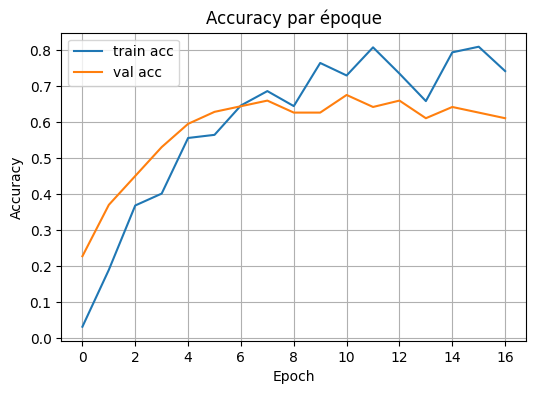

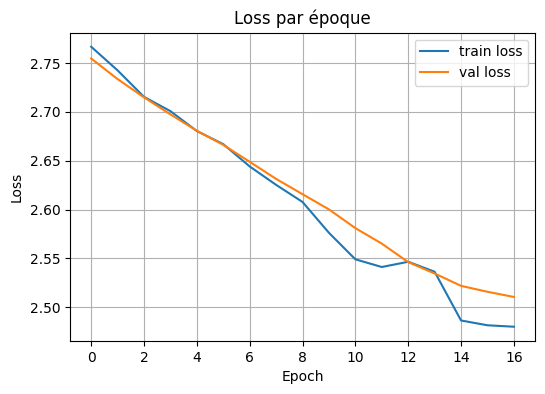

In [11]:
# =========================================================
# 📈 Plot accuracy & loss
# =========================================================
plt.figure(figsize=(6,4))
plt.plot(history["train_acc"], label="train acc")
plt.plot(history["val_acc"], label="val acc")
plt.title("Accuracy par époque")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.title("Loss par époque")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True)
plt.show()


Évaluation finale (test set), matrice de confusion & rapport

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                     precision    recall  f1-score   support

   Albus Dumbledore       0.67      0.50      0.57         4
     Arthur Weasley       0.67      0.67      0.67         3
Bellatrix Lestrange       0.75      0.75      0.75         4
        Dean Thomas       1.00      0.75      0.86         4
       Draco Malfoy       1.00      0.33      0.50         3
      Ginny Weasley       0.00      0.00      0.00         3
       Harry Potter       0.80      1.00      0.89         4
   Hermione Granger       0.80      1.00      0.89         4
     Lord Voldemort       0.33      0.75      0.46         4
      Luna Lovegood       0.83      1.00      0.91         5
 Minerva McGonagall       1.00      0.75      0.86         4
      Molly Weasley       1.00      0.75      0.86         4
 Neville Longbottom       0.67      0.50      0.57         4
        Ron Weasley       1.00      1.00      1.00         3
      Rubeus Hagrid       1.00      0.50      0.67         4
      Severus Snape    

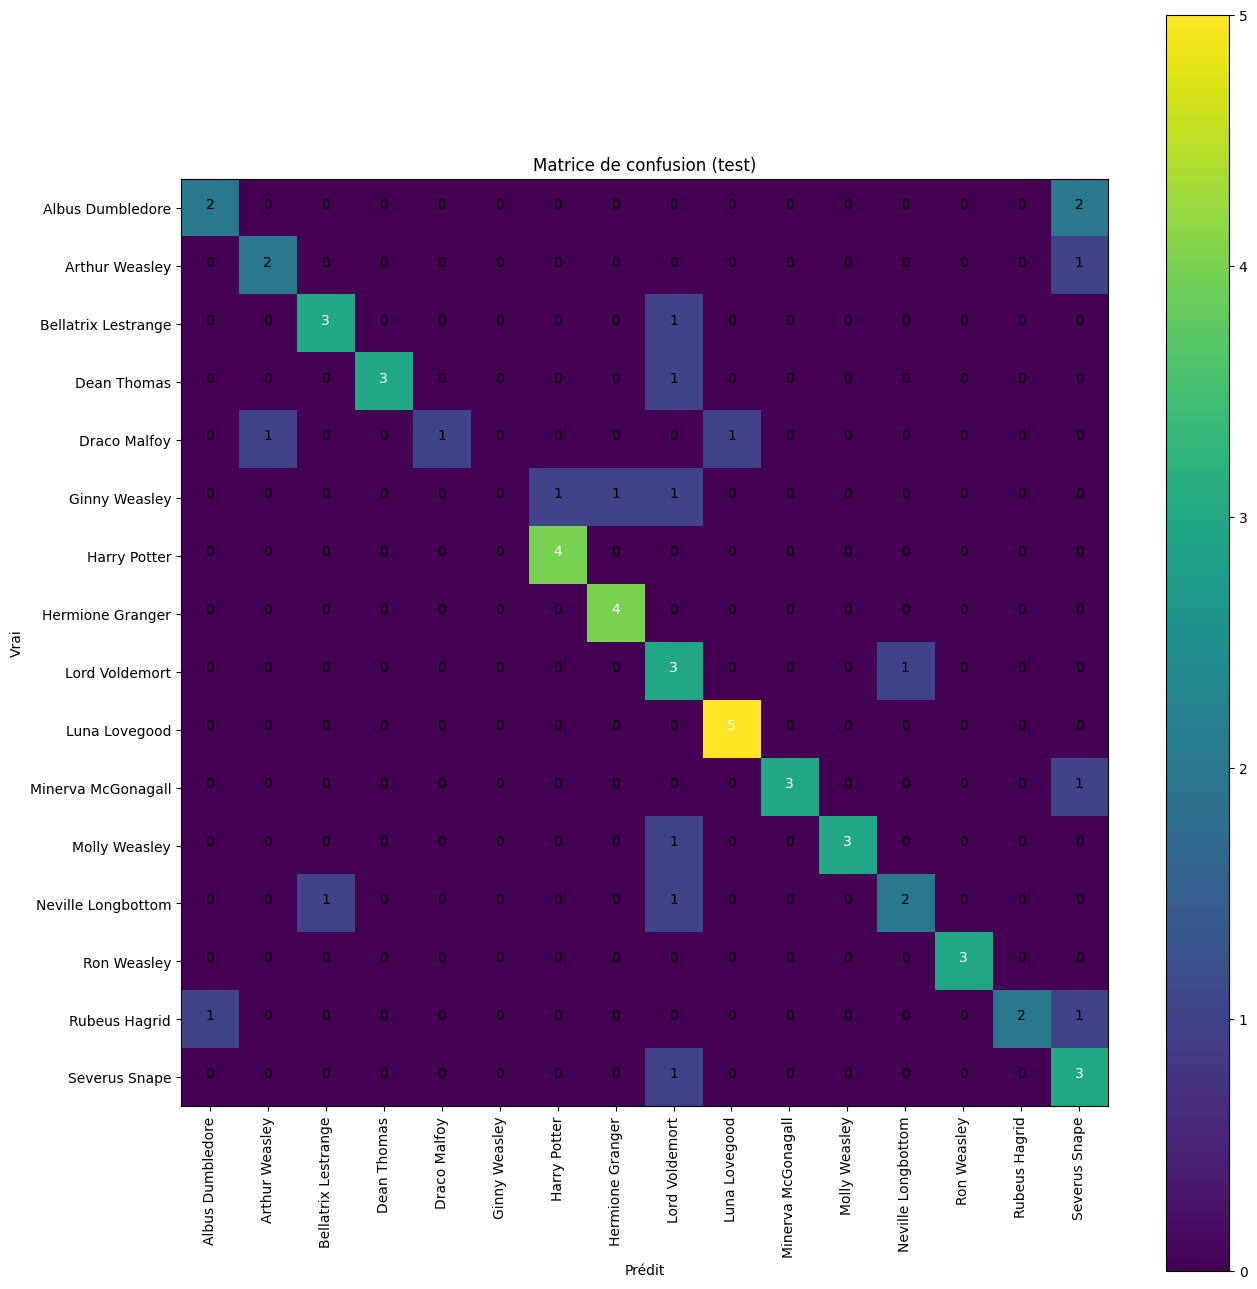

In [12]:
# =========================================================
# 🧪 Evaluation on test set + confusion matrix
# =========================================================
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(1).cpu().numpy().tolist()
        y_pred += preds
        y_true += y.numpy().tolist()

# Rapport
print(classification_report(y_true, y_pred, target_names=[idx_to_class[i] for i in range(len(idx_to_class))]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
classes = [idx_to_class[i] for i in range(len(idx_to_class))]

plt.figure(figsize=(0.6*len(classes)+4, 0.6*len(classes)+4))
plt.imshow(cm, interpolation='nearest')
plt.title("Matrice de confusion (test)")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=90)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")
plt.ylabel('Vrai'); plt.xlabel('Prédit')
plt.tight_layout()
plt.show()


Débloquer encore plus de perf

In [13]:
# =========================================================
# 🔧 Fine-tuning optionnel du backbone (quelques couches)
# A lancer SEULEMENT si vous voulez gratter les derniers points.
# =========================================================
# On "dégèle" le dernier bloc du backbone pour un très léger fine-tuning
for name, p in model[0].named_parameters():
    if "block8" in name or "last_linear" in name:
        p.requires_grad = True

# Optimiseur pour tout ce qui est entraînable
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=3e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

EPOCHS_FT = 10
for epoch in range(1, EPOCHS_FT+1):
    model.train(); tr_acc=0; tr_loss=0; n=0
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item()
        tr_acc  += (logits.argmax(1)==y).float().mean().item()
        n+=1
    tr_loss/=n; tr_acc/=n

    model.eval(); va_acc=0; va_loss=0; n=0
    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            va_loss += loss.item()
            va_acc  += (logits.argmax(1)==y).float().mean().item()
            n+=1
    va_loss/=n; va_acc/=n
    scheduler.step(va_acc)
    print(f"[FT {epoch:02d}/{EPOCHS_FT}] loss {tr_loss:.3f}/{va_loss:.3f} | acc {tr_acc:.3f}/{va_acc:.3f}")


[FT 01/10] loss 2.559/2.572 | acc 0.804/0.642
[FT 02/10] loss 2.535/2.565 | acc 0.816/0.675
[FT 03/10] loss 2.537/2.562 | acc 0.760/0.659
[FT 04/10] loss 2.515/2.553 | acc 0.806/0.613
[FT 05/10] loss 2.525/2.553 | acc 0.757/0.659
[FT 06/10] loss 2.513/2.548 | acc 0.793/0.659
[FT 07/10] loss 2.525/2.543 | acc 0.700/0.644
[FT 08/10] loss 2.496/2.541 | acc 0.852/0.644
[FT 09/10] loss 2.510/2.536 | acc 0.750/0.644
[FT 10/10] loss 2.495/2.538 | acc 0.774/0.644


Sauvegarde du modele


In [14]:
# =========================================================
# 💾 Sauvegarde PyTorch : modèle complet + state_dict + métadonnées
# =========================================================
import torch, json
from pathlib import Path

save_dir = Path("export_model")
save_dir.mkdir(parents=True, exist_ok=True)

# -- Essayer de récupérer automatiquement classes, input_size, normalisation --
def _get_classes():
    for name in ["class_names","CLASSES","classes"]:
        if name in globals() and isinstance(globals()[name], (list,tuple)):
            return list(globals()[name])
    # torchvision ImageFolder
    for name in ["train_ds","train_dataset","train_data"]:
        if name in globals():
            ds = globals()[name]
            if hasattr(ds, "classes"): return list(ds.classes)
    return None

def _get_input_size():
    for name in ["input_size","IMG_SIZE","img_size"]:
        if name in globals():
            v = globals()[name]
            if isinstance(v,(list,tuple)) and len(v)>=2: return [int(v[0]), int(v[1])]
    # si tu as défini transforms.Resize((H,W))
    for tname in ["train_tf","transform_train","tfm_train","transform"]:
        if tname in globals():
            tf = globals()[tname]
            try:
                for t in tf.transforms:
                    if t.__class__.__name__.lower().startswith("resize") and hasattr(t, "size"):
                        s = t.size
                        if isinstance(s, (list,tuple)):
                            return [int(s[0]), int(s[1])] if len(s)==2 else [int(s), int(s)]
            except Exception: pass
    return [224, 224]

def _get_norm():
    # essaie de trouver mean/std dans tes transforms
    for tname in ["train_tf","transform_train","tfm_train","transform"]:
        if tname in globals():
            tf = globals()[tname]
            try:
                for t in tf.transforms:
                    if t.__class__.__name__.lower()=="normalize":
                        return list(t.mean), list(t.std)
            except Exception: pass
    return [0.5,0.5,0.5], [0.5,0.5,0.5]

classes = _get_classes()
input_size = _get_input_size()
mean, std = _get_norm()

# -- Sauvegardes --
full_path = save_dir / "hp_cnn_full.pt"      # modèle complet (pickle)
state_path = save_dir / "hp_cnn_state.pth"   # uniquement les poids

torch.save(model, full_path)
torch.save({"state_dict": model.state_dict()}, state_path)

metadata = {
    "classes": classes,
    "input_size": input_size,
    "normalize_mean": mean,
    "normalize_std": std
}
with open(save_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Modèle complet : {full_path}")
print(f"✅ State dict     : {state_path}")
print(f"✅ Métadonnées    : {save_dir/'metadata.json'}")
print(f"🔎 classes={classes}\n🔎 input_size={input_size}\n🔎 mean={mean}, std={std}")


✅ Modèle complet : export_model/hp_cnn_full.pt
✅ State dict     : export_model/hp_cnn_state.pth
✅ Métadonnées    : export_model/metadata.json
🔎 classes=['Albus Dumbledore', 'Arthur Weasley', 'Bellatrix Lestrange', 'Dean Thomas', 'Draco Malfoy', 'Ginny Weasley', 'Harry Potter', 'Hermione Granger', 'Lord Voldemort', 'Luna Lovegood', 'Minerva McGonagall', 'Molly Weasley', 'Neville Longbottom', 'Ron Weasley', 'Rubeus Hagrid', 'Severus Snape']
🔎 input_size=[224, 224]
🔎 mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]


In [15]:
##


Test d’une image utilisateur

Saving Daniel Radcliffe (18).jpg to Daniel Radcliffe (18).jpg
🖼️ Image chargée: Daniel Radcliffe (18).jpg


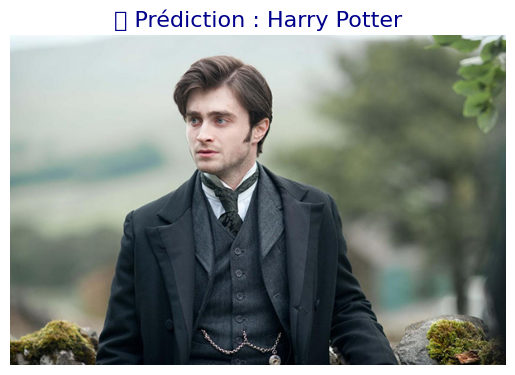

In [17]:
# =========================================================
# 🧙‍♂️ Prédiction sur une image utilisateur
# =========================================================


# 1️⃣ Charger une image depuis ton ordi
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
print(f"🖼️ Image chargée: {file_name}")

# 2️⃣ Recadrer le visage avec MTCNN
mtcnn_eval = MTCNN(image_size=160, margin=20, post_process=True, keep_all=False, device=device)

img = Image.open(file_name).convert("RGB")
face = mtcnn_eval(img)

if face is None:
    print("❌ Aucun visage détecté. Essaie une autre image.")
else:
    # 3️⃣ Normalisation identique à l'entraînement
    face = (face - 0.5) / 0.5  # même normalisation [-1,1]
    face = face.unsqueeze(0).to(device)

    # 4️⃣ Prédiction
    model.eval()
    with torch.no_grad():
        logits = model(face)
        pred = torch.argmax(logits, dim=1).item()
        pred_class = idx_to_class[pred]

    # 5️⃣ Affichage
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"🔮 Prédiction : {pred_class}", fontsize=16, color="darkblue")
    plt.show()
